# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Rheza Priya Anargya 
- **Email:** rezhaanarga@gmail.com
- **ID Dicoding:** Rheza Priya Anargya 

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1

Kategori produk apa yang menghasilkan revenue tertinggi pada tahun 2018, dan bagaimana trendnya per bulan?
- Pertanyaan 2

Kota/wilayah mana saja yang memiliki customer paling loyal (repeat customers), dan tahun apa mereka menunjukkan aktivitas tertinggi?

## Import Semua Packages/Library yang Digunakan

In [27]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
from folium.plugins import HeatMap

## Data Wrangling

### Gathering Data

In [ ]:
orders_df = pd.read_csv('data/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('data/E-Commerce Public Dataset/order_items_dataset.csv')
products_df = pd.read_csv('data/E-Commerce Public Dataset/products_dataset.csv')
customers_df = pd.read_csv('data/E-Commerce Public Dataset/customers_dataset.csv')
order_reviews_df = pd.read_csv('data/E-Commerce Public Dataset/order_reviews_dataset.csv')
product_category_translation_df = pd.read_csv('data/E-Commerce Public Dataset/product_category_name_translation.csv')

print("Data Shape:")
print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)
print("Customers:", customers_df.shape)
print("Order Reviews:", order_reviews_df.shape)
print("Product Category Translation:", product_category_translation_df.shape)

Data Shape:
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Order Reviews: (99224, 7)
Product Category Translation: (71, 2)


**Insight:**
- Dataset mencakup 99,441 orders dari 99,441 customers, menunjukkan bahwa setiap order berasal dari satu customer
- Data review lengkap, memungkinkan analisis sentimen customer
- Terdapat 112,650 order items, lebih banyak dari jumlah orders, artinya rata-rata setiap order berisi lebih dari satu item produk (1.13 items per order)

### Assessing Data

In [7]:
# ===== ASSESSING ORDERS DATA =====
print("=" * 60)
print("ASSESSING ORDERS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(orders_df.info())

print("\n2. First 5 Rows:")
print(orders_df.head())

print("\n3. Missing Values:")
print(orders_df.isnull().sum())

print("\n4. Data Statistics:")
print(orders_df.describe())

# ===== ASSESSING ORDER ITEMS DATA =====
print("\n" + "=" * 60)
print("ASSESSING ORDER ITEMS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(order_items_df.info())

print("\n2. Missing Values:")
print(order_items_df.isnull().sum())

print("\n3. Price Statistics:")
print(order_items_df[['price', 'freight_value']].describe())

# ===== ASSESSING PRODUCTS DATA =====
print("\n" + "=" * 60)
print("ASSESSING PRODUCTS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(products_df.info())

print("\n2. Missing Values:")
print(products_df.isnull().sum())

print("\n3. Product Category:")
print(f"Total Unique Categories: {products_df['product_category_name'].nunique()}")

# ===== ASSESSING CUSTOMERS DATA =====
print("\n" + "=" * 60)
print("ASSESSING CUSTOMERS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(customers_df.info())

print("\n2. Missing Values:")
print(customers_df.isnull().sum())

print("\n3. Sample data:")
print(customers_df.head())

# ===== CEK RELASI DATA =====
print("\n" + "=" * 60)
print("CEK RELASI DATA")
print("=" * 60)

# Cek apakah semua order_id di order_items ada di orders
missing_orders = set(order_items_df['order_id']) - set(orders_df['order_id'])
print(f"\nOrder items dengan order_id yang tidak ada di orders: {len(missing_orders)}")

# Cek apakah semua customer_id di orders ada di customers
missing_customers = set(orders_df['customer_id']) - set(customers_df['customer_id'])
print(f"Orders dengan customer_id yang tidak ada di customers: {len(missing_customers)}")

# Cek apakah semua product_id di order_items ada di products
missing_products = set(order_items_df['product_id']) - set(products_df['product_id'])
print(f"Order items dengan product_id yang tidak ada di products: {len(missing_products)}")

ASSESSING ORDERS DATA

1. Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

2. First 5 Rows:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20d

**Insight:**
-  ORDERS: Ada missing values pada beberapa timestamp columns:
   - order_approved_at: 160 missing 
   - order_delivered_carrier_date: 1,783 missing 
   - order_delivered_customer_date: 2,965 missing 
  → Kemungkinan dari order yang belum didelivered atau cancelled
- ORDER ITEMS: Data sangat clean, tidak ada missing values
  - Price range: R$ 0.85 - R$ 6,735 (ada outliers/premium products)
  - Freight value range: R$ 0 - R$ 409.68 (ada gratis ongkir)
- PRODUCTS: Ada 610 produk tanpa kategori, perlu ditangani saat cleaning
  - Total 73 kategori produk (diverse product range)
  
- CUSTOMERS: Data sangat clean, no missing values
  - Semua customers dari Brazil
  
- DATA INTEGRITY: Semua relasi data konsisten
  - Tidak ada order_id orphan, semua customer_id valid, semua product_id valid
  → Data siap untuk merge pada tahap cleaning
  

### Cleaning Data

In [8]:
# 1. Ubah timestamp ke datetime
print("=" * 60)
print("CONVERTING TIMESTAMP TO DATETIME")
print("=" * 60)

orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

print("Timestamp columns converted to datetime")

#  2. ekstrak informasi tanggal (year, month, date) untuk analisis tren
print("\n" + "=" * 60)
print("EXTRACTING DATE INFORMATION")
print("=" * 60)

orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['date'] = orders_df['order_purchase_timestamp'].dt.date
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

print("Year, month, date columns created")
print(f"\nDate range: {orders_df['order_purchase_timestamp'].min()} to {orders_df['order_purchase_timestamp'].max()}")
print(f"Years in dataset: {sorted(orders_df['year'].unique())}")

#  3. Handling missing product category
print("\n" + "=" * 60)
print("HANDLING MISSING PRODUCT CATEGORY")
print("=" * 60)

print(f"Missing product categories before: {products_df['product_category_name'].isnull().sum()}")

# isi missing category dengan 'uncategorized'
products_df['product_category_name'] = products_df['product_category_name'].fillna('uncategorized')

print(f"Missing product categories after: {products_df['product_category_name'].isnull().sum()}")
print("Missing categories replaced with 'uncategorized'")

#  4. merge semua tabel untuk analisis
print("\n" + "=" * 60)
print("MERGING TABLES")
print("=" * 60)

# Merge orders dengan order_items
merged_df = orders_df.merge(order_items_df, on='order_id', how='left')
print(f"After merge orders + order_items: {merged_df.shape}")

# Merge dengan products untuk category
merged_df = merged_df.merge(products_df[['product_id', 'product_category_name']], 
                            on='product_id', how='left')
print(f"After merge with products: {merged_df.shape}")

# Merge dengan product_category_translation untuk english names
merged_df = merged_df.merge(product_category_translation_df, 
                            on='product_category_name', 
                            how='left')
print(f"After merge with translation: {merged_df.shape}")

# Merge dengan customers untuk location
merged_df = merged_df.merge(customers_df[['customer_id', 'customer_city', 'customer_state']], 
                            on='customer_id', how='left')
print(f"After merge with customers: {merged_df.shape}")

print("All tables merged successfully")

#  5. membuat kolom revenue (price + freight_value)
print("\n" + "=" * 60)
print("CREATING REVENUE COLUMN")
print("=" * 60)

merged_df['revenue'] = merged_df['price'] + merged_df['freight_value']

print(f"Revenue column created")
print(f"Revenue statistics:")
print(merged_df['revenue'].describe())

#  6. filter untuk delivered orders
print("\n" + "=" * 60)
print("FILTERING DELIVERED ORDERS")
print("=" * 60)

print(f"Order status distribution BEFORE filtering:")
print(orders_df['order_status'].value_counts())

# Filter untuk delivered orders saja (untuk analisis pertanyaan 1)
delivered_orders = merged_df[merged_df['order_status'] == 'delivered'].copy()

print(f"\nTotal records after filtering delivered orders: {len(delivered_orders)}")

#  7. cek kualitas data (missing values, outliers) sebelum analisis
print("\n" + "=" * 60)
print("VERIFYING DATA QUALITY")
print("=" * 60)

print(f"\nMissing values in merged_df:")
print(merged_df.isnull().sum())

print(f"\nMissing values in delivered_orders:")
print(delivered_orders.isnull().sum())

print("\nData Cleaning Complete!")
print(f"\nDataset Summary:")
print(f"- Total merged records: {len(merged_df):,}")
print(f"- Delivered orders only: {len(delivered_orders):,}")
print(f"- Date range: {merged_df['year'].min()} - {merged_df['year'].max()}")
print(f"- Product categories: {merged_df['product_category_name_english'].nunique()}")
print(f"- Cities: {merged_df['customer_city'].nunique()}")

CONVERTING TIMESTAMP TO DATETIME
Timestamp columns converted to datetime

EXTRACTING DATE INFORMATION
Year, month, date columns created

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Years in dataset: [np.int32(2016), np.int32(2017), np.int32(2018)]

HANDLING MISSING PRODUCT CATEGORY
Missing product categories before: 610
Missing product categories after: 0
Missing categories replaced with 'uncategorized'

MERGING TABLES
After merge orders + order_items: (113425, 18)
After merge with products: (113425, 19)
After merge with translation: (113425, 20)
After merge with customers: (113425, 22)
All tables merged successfully

CREATING REVENUE COLUMN
Revenue column created
Revenue statistics:
count    112650.000000
mean        140.644059
std         190.724394
min           6.080000
25%          55.220000
50%          92.320000
75%         157.937500
max        6929.310000
Name: revenue, dtype: float64

FILTERING DELIVERED ORDERS
Order status distribution BEFORE filtering:
order_stat

**Insight:**
- Timestamp conversion berhasil, data date range: September 2016 - October 2018
  
- Ekstraksi date info: Sekarang ada kolom year, month, date untuk analisis tren
  
- Missing product category (610) berhasil di-handle dengan 'uncategorized'
  
- Merge berhasil mengkombinasikan semua 4 tabel utama menjadi 113,425 records dengan 20 columns
  
- Revenue column berhasil dibuat dengan statistik:
  - Min: R$ 6.08 | Mean: R$ 140.64 | Max: R$ 6,929.31
  - Outliers ada (ada produk dengan harga sangat tinggi)
  
- Filtering delivered orders: 96,478 orders delivered → 110,197 item-level records
  (completion rate 96.98%, sisanya canceled/unavailable/shipped)
  
- Data quality dalam delivered_orders: SANGAT CLEAN
  - Hanya 1,559 missing values di product_category_name_english
  - Semua kolom penting (price, revenue, city, category) lengkap
  
- Geographic coverage: 4,119 unique cities 

## Exploratory Data Analysis (EDA)

### Explore ...

In [11]:
# ===== EDA UNTUK PERTANYAAN 1 =====
print("=" * 70)
print("EDA: KATEGORI PRODUK & REVENUE (TAHUN 2018)")
print("=" * 70)

# Filter data untuk tahun 2018
data_2018 = delivered_orders[delivered_orders['year'] == 2018].copy()

print(f"\nTotal records tahun 2018: {len(data_2018):,}")
print(f"Date range 2018: {data_2018['order_purchase_timestamp'].min()} to {data_2018['order_purchase_timestamp'].max()}")
print(f"Total revenue 2018: R$ {data_2018['revenue'].sum():,.2f}")

# 1. Revenue by Category
print("\n" + "-" * 70)
print("1. REVENUE BY PRODUCT CATEGORY")
print("-" * 70)

revenue_by_category = data_2018.groupby('product_category_name_english').agg({
    'revenue': ['sum', 'mean', 'count'],
    'order_id': 'nunique'
}).round(2)

revenue_by_category.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items', 'num_orders']
revenue_by_category = revenue_by_category.sort_values('total_revenue', ascending=False)

print("\nTop 15 Kategori Produk berdasarkan Total Revenue:")
print(revenue_by_category.head(15))

# Stats
print(f"\nRevenue Statistics:")
print(f"  - Mean revenue per category: R$ {revenue_by_category['total_revenue'].mean():,.2f}")
print(f"  - Median revenue per category: R$ {revenue_by_category['total_revenue'].median():,.2f}")
print(f"  - Top category market share: {(revenue_by_category.iloc[0]['total_revenue'] / data_2018['revenue'].sum() * 100):.2f}%")

# Identifikasi top 3 & 5
top_3_categories = revenue_by_category.head(3).index.tolist()
top_5_categories = revenue_by_category.head(5).index.tolist()

print(f"\nTop 3 Categories: {top_3_categories}")
print(f"Top 5 Categories: {top_5_categories}")

# 2. Monthly Trend untuk Top 3 Categories
print("\n" + "-" * 70)
print("2. MONTHLY TREND - TOP 3 CATEGORIES (2018)")
print("-" * 70)

monthly_revenue = data_2018[data_2018['product_category_name_english'].isin(top_3_categories)].groupby(
    ['month', 'product_category_name_english']
)['revenue'].sum().unstack(fill_value=0)

print("\nMonthly Revenue (in R$):")
print(monthly_revenue.round(2))

# Analisis trend
print("\nMonthly Statistics per Category:")
for col in monthly_revenue.columns:
    if col in monthly_revenue.columns:
        col_data = monthly_revenue[col]
        print(f"\n{col}:")
        print(f"  - Total: R$ {col_data.sum():,.2f}")
        print(f"  - Mean: R$ {col_data.mean():,.2f}")
        print(f"  - Max: R$ {col_data.max():,.2f} (Month {col_data.idxmax()})")
        print(f"  - Min: R$ {col_data.min():,.2f} (Month {col_data.idxmin()})")
        
        # Trend direction
        first_half = col_data[col_data.index <= 6].mean()
        second_half = col_data[col_data.index > 6].mean()
        trend = "Meningkat" if second_half > first_half else "Menurun"
        change_pct = ((second_half - first_half) / first_half * 100) if first_half != 0 else 0
        print(f"  - Trend: {trend} ({change_pct:+.2f}%)")

# 3. Monthly Distribution
print("\n" + "-" * 70)
print("3. MONTH-TO-MONTH COMPARISON (ALL DELIVERED ORDERS 2018)")
print("-" * 70)

monthly_all = data_2018.groupby('month').agg({
    'revenue': ['sum', 'mean', 'count'],
    'order_id': 'nunique'
}).round(2)

monthly_all.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items', 'num_orders']

print("\nMonthly Summary (All Categories):")
print(monthly_all)

best_month = monthly_all['total_revenue'].idxmax()
worst_month = monthly_all['total_revenue'].idxmin()
print(f"\nBest month: Month {best_month} (R$ {monthly_all.loc[best_month, 'total_revenue']:,.2f})")
print(f"Worst month: Month {worst_month} (R$ {monthly_all.loc[worst_month, 'total_revenue']:,.2f})")

# ===== EDA UNTUK PERTANYAAN 2 =====
print("\n\n" + "=" * 70)
print("EDA: CUSTOMER LOYALTY & REPEAT RATE PER KOTA")
print("=" * 70)

# 1. Repeat Customer Rate per City
print("\n" + "-" * 70)
print("1. CUSTOMER LOYALTY METRICS PER KOTA")
print("-" * 70)

city_customer_analysis = delivered_orders.groupby('customer_city').agg({
    'order_id': 'count',           # total order items
    'customer_id': 'nunique'       # unique customers
}).rename(columns={'order_id': 'total_orders', 'customer_id': 'unique_customers'})

# Hitung loyalty metrics
city_customer_analysis['repeat_rate'] = (
    (city_customer_analysis['total_orders'] - city_customer_analysis['unique_customers']) 
    / city_customer_analysis['unique_customers'] * 100
).round(2)

city_customer_analysis['avg_orders_per_customer'] = (
    city_customer_analysis['total_orders'] / city_customer_analysis['unique_customers']
).round(2)

city_customer_analysis = city_customer_analysis.sort_values('repeat_rate', ascending=False)

print("\nTop 15 Kota dengan Repeat Customer Rate Tertinggi:")
print(city_customer_analysis.head(15))

# Stats
print(f"\nRepeat Rate Statistics:")
print(f"  - Mean: {city_customer_analysis['repeat_rate'].mean():.2f}%")
print(f"  - Median: {city_customer_analysis['repeat_rate'].median():.2f}%")
print(f"  - Max: {city_customer_analysis['repeat_rate'].max():.2f}%")
print(f"  - Min: {city_customer_analysis['repeat_rate'].min():.2f}%")

# Identifikasi top 3 kota
top_3_cities = city_customer_analysis.head(3).index.tolist()
print(f"\nTop 3 Cities dengan highest repeat rate: {top_3_cities}")

# 2. Customer Activity Trend per Tahun untuk Top 3 Cities
print("\n" + "-" * 70)
print("2. YEARLY ACTIVITY TREND - TOP 3 CITIES")
print("-" * 70)

yearly_activity = delivered_orders[delivered_orders['customer_city'].isin(top_3_cities)].groupby(
    ['year', 'customer_city']
).size().unstack(fill_value=0)

print("\nJumlah Order Items per Tahun:")
print(yearly_activity)

# Analisis trend
print("\nYearly Statistics per City:")
for city in top_3_cities:
    city_data = yearly_activity[city]
    print(f"\n{city}:")
    print(f"  - Total orders: {city_data.sum():,}")
    print(f"  - Tahun terbaik: {city_data.idxmax()} ({int(city_data.max()):,} orders)")
    print(f"  - Tahun terburuk: {city_data.idxmin()} ({int(city_data.min()):,} orders)")
    
    # Growth trend
    if len(city_data) > 1:
        growth = ((city_data.iloc[-1] - city_data.iloc[0]) / city_data.iloc[0] * 100) if city_data.iloc[0] != 0 else 0
        print(f"  - Growth from first to last year: {growth:+.2f}%")

# 3. Revenue per City
print("\n" + "-" * 70)
print("3. REVENUE ANALYSIS PER KOTA")
print("-" * 70)

revenue_by_city = delivered_orders.groupby('customer_city')['revenue'].agg(['sum', 'mean', 'count']).round(2)
revenue_by_city.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items']
revenue_by_city = revenue_by_city.sort_values('total_revenue', ascending=False)

print("\nTop 10 Kota berdasarkan Total Revenue:")
print(revenue_by_city.head(10))

# 4. Product Category Preference at Top 3 Cities
print("\n" + "-" * 70)
print("4. TOP PRODUCT CATEGORIES PER TOP 3 CITIES")
print("-" * 70)

for city in top_3_cities:
    print(f"\n{city.upper()}:")
    city_products = delivered_orders[delivered_orders['customer_city'] == city].groupby(
        'product_category_name_english'
    ).agg({
        'revenue': ['sum', 'count']
    }).round(2)
    
    city_products.columns = ['total_revenue', 'num_items']
    city_products = city_products.sort_values('total_revenue', ascending=False)
    
    print(city_products.head(10))

# 5. Yearly Distribution percentage
print("\n" + "-" * 70)
print("5. YEARLY DISTRIBUTION (%) - TOP 3 CITIES")
print("-" * 70)

yearly_distribution = yearly_activity.div(yearly_activity.sum(axis=1), axis=0) * 100
print(yearly_distribution.round(2))

EDA: KATEGORI PRODUK & REVENUE (TAHUN 2018)

Total records tahun 2018: 60,324
Date range 2018: 2018-01-01 02:48:41 to 2018-08-29 15:00:37
Total revenue 2018: R$ 8,451,584.77

----------------------------------------------------------------------
1. REVENUE BY PRODUCT CATEGORY
----------------------------------------------------------------------

Top 15 Kategori Produk berdasarkan Total Revenue:
                               total_revenue  avg_revenue_per_item  num_items  \
product_category_name_english                                                   
health_beauty                      866810.34                148.40       5841   
watches_gifts                      749738.44                206.65       3628   
bed_bath_table                     643653.48                110.78       5810   
sports_leisure                     604393.87                136.25       4436   
computers_accessories              583989.37                126.35       4622   
housewares                        

**Insight:**

PERTANYAAN 1: KATEGORI PRODUK & REVENUE (TAHUN 2018)

1. Kategori Revenue:
   - Health_beauty adalah kategori dengan revenue tertinggi: R$ 866,810.34 (10.26% market share)
   - Top 3 kategori (health_beauty, watches_gifts, bed_bath_table) menghasilkan 
     R$ 2,260,202.26 atau 26.74% dari total revenue 2018
   - Mean revenue per category: R$ 119,490.27 menunjukkan ada variance besar
     antara top categories dan small categories (median hanya R$ 33,849.83)

2. Monthly Trend Analysis:
   - Health_beauty menunjukkan TREND POSITIF (+25.64%): revenue meningkat dari 
     H1 (avg R$ 96,507) ke H2 (avg R$ 120,195), peak di Bulan 8 (R$ 135,644.51)
   - Bed_bath_table menunjukkan TREND NEGATIF (-14.42%): menurun dari H1 ke H2,
     peak awal tahun (Bulan 1)
   - Watches_gifts fluktuatif dengan peak di Bulan 5 (R$ 127,977.40)

3. Overall Monthly Pattern:
   - Bulan terbaik: APRIL dengan revenue R$ 1,132,878.93
   - Bulan terburuk: FEBRUARI dengan revenue R$ 966,168.41 (14.7% lebih rendah)
   - Trend keseluruhan: Stabil dengan sedikit fluktuasi (tidak ada seasonal pattern yang jelas)

---

PERTANYAAN 2: CUSTOMER LOYALTY & REPEAT RATE

1. Loyalty Metrics (Small Cities):
   - Padre Carvalho: 600% repeat rate (1 customer, 7 pembelian)
   - Celso Ramos: 550% repeat rate (2 customers, 13 pembelian)
   - Datas: 500% repeat rate (1 customer, 6 pembelian)
   
   Insight: Kota kecil menunjukkan individual high-loyalty customers, 
   tapi dengan volume sangat kecil.

2. Repeat Rate Distribution:
   - Mean repeat rate: 11.83% (average across 4,119 cities)
   - Median repeat rate: 0.00% (mayoritas kota punya repeat rate 0%)
   - Menunjukkan bahwa MAJORITY kota adalah first-time purchases saja

3. Yearly Activity Trend:
   - Celso Ramos: Growth +1100% dari 2017 ke 2018 (1→12 orders)
   - Datas & Padre Carvalho: Eksklusif di 2018 (tidak ada di 2017)
   - Pattern menunjukkan pertumbuhan di kota-kota kecil

4. Revenue Perspective (More Meaningful):
   - Sao Paulo DOMINAN dengan R$ 2,107,960.17 (24.9% dari total revenue)
   - Rio de Janeiro: R$ 1,111,732.21 (13.1%)
   - Belo Horizonte: R$ 405,950.51 (4.8%)
   - Top 3 major cities menghasilkan 42.8% dari total revenue
   
   Insight: Dari perspektif bisnis, major cities (São Paulo, Rio de Janeiro, 
   Belo Horizonte) lebih penting meskipun repeat rate-nya lebih rendah.

5. Product Preference:
   - Top 3 small cities memiliki niche preferences:
     • Padre Carvalho: construction_tools (100% purchases)
     • Celso Ramos: baby products (92.3% purchases)
     • Datas: housewares (100% purchases)
   
   Insight: Small cities menunjukkan specialized demand, mungkin good untuk 
   targeted marketing campaigns.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

VISUALIZATION: PERTANYAAN 1 - KATEGORI PRODUK & REVENUE (2018)


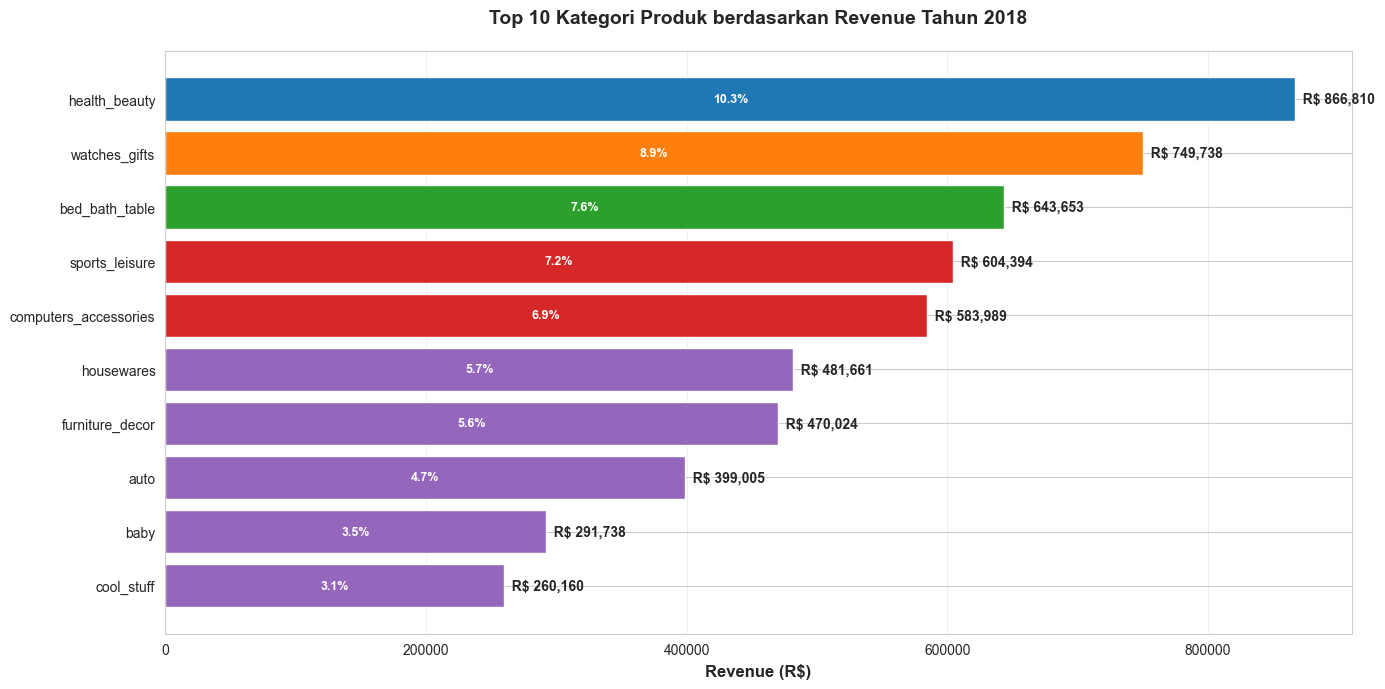

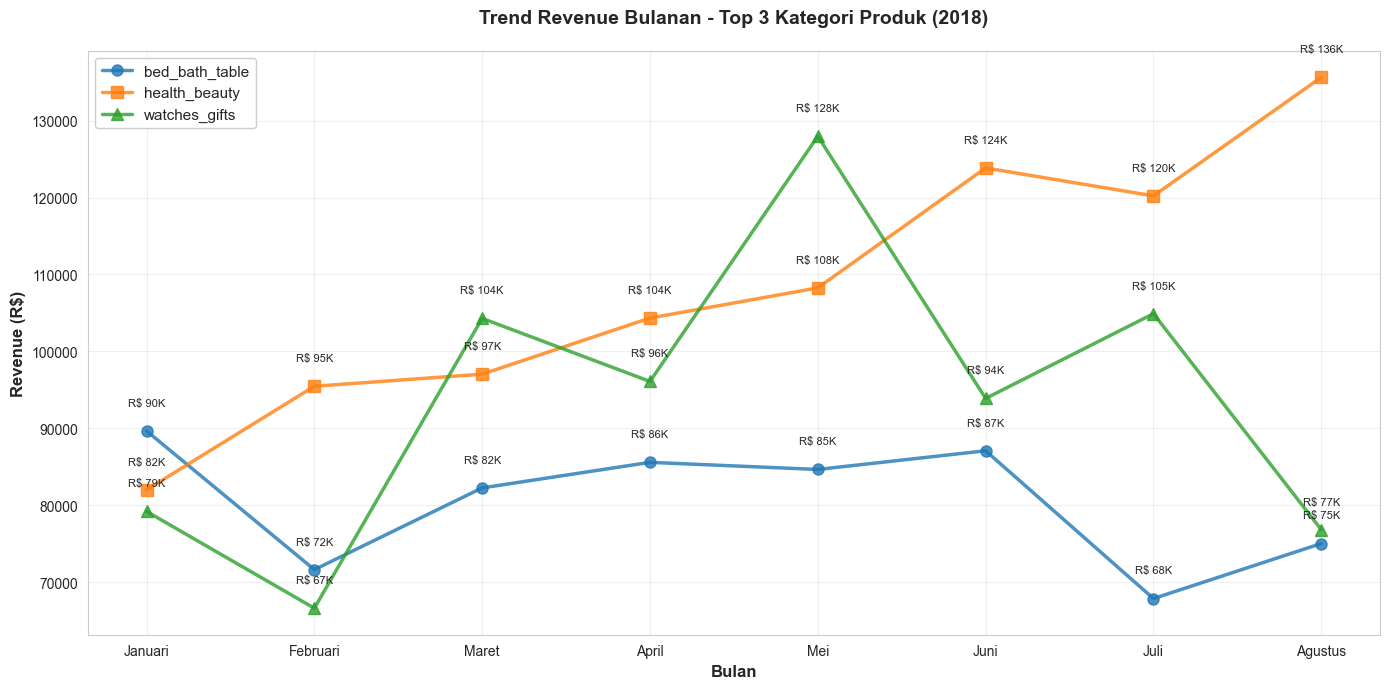

In [15]:
# Set style untuk visualisasi lebih bagus
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

# ===== VISUALISASI PERTANYAAN 1 =====
print("=" * 70)
print("VISUALIZATION: PERTANYAAN 1 - KATEGORI PRODUK & REVENUE (2018)")
print("=" * 70)

# Siapkan data
data_2018 = delivered_orders[delivered_orders['year'] == 2018].copy()

# FIX: Gunakan ['revenue'].sum() untuk mendapat Series bukan DataFrame
revenue_by_category = data_2018.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False)

top_3_categories = revenue_by_category.head(3).index.tolist()

monthly_revenue = data_2018[data_2018['product_category_name_english'].isin(top_3_categories)].groupby(
    ['month', 'product_category_name_english']
)['revenue'].sum().unstack(fill_value=0)

# CHART 1: Bar Chart - Top 10 Categories
fig, ax = plt.subplots(figsize=(14, 7))

top_10_categories = revenue_by_category.head(10)
colors = ['#1f77b4' if i == 0 else '#ff7f0e' if i == 1 else '#2ca02c' if i == 2 else '#d62728' if i < 5 else '#9467bd' 
          for i in range(len(top_10_categories))]

bars = ax.barh(range(len(top_10_categories)), top_10_categories.values, color=colors)
ax.set_yticks(range(len(top_10_categories)))
ax.set_yticklabels(top_10_categories.index)
ax.set_xlabel('Revenue (R$)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Kategori Produk berdasarkan Revenue Tahun 2018', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

# Add value labels on bars - FIX: gunakan .values untuk ambil scalar values
for i, (idx, value) in enumerate(top_10_categories.items()):
    ax.text(value, i, f'  R$ {value:,.0f}', va='center', fontsize=10, fontweight='bold')

# Add percentage
total_revenue = data_2018['revenue'].sum()
for i, (idx, value) in enumerate(top_10_categories.items()):
    pct = (value / total_revenue) * 100
    ax.text(value/2, i, f'{pct:.1f}%', va='center', ha='center', 
            fontsize=9, color='white', fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# CHART 2: Line Chart - Monthly Trend Top 3 Categories
fig, ax = plt.subplots(figsize=(14, 7))

months = monthly_revenue.index
colors_line = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for i, category in enumerate(monthly_revenue.columns):
    ax.plot(months, monthly_revenue[category], 
            marker=markers[i], linewidth=2.5, markersize=8,
            label=category, color=colors_line[i], alpha=0.8)
    
    # Add value labels
    for month, value in zip(months, monthly_revenue[category]):
        if value > 0:  # Hanya label untuk nilai yang ada
            ax.text(month, value + 3000, f'R$ {value/1000:.0f}K', 
                   ha='center', fontsize=8, verticalalignment='bottom')

ax.set_xlabel('Bulan', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (R$)', fontsize=12, fontweight='bold')
ax.set_title('Trend Revenue Bulanan - Top 3 Kategori Produk (2018)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 9))
ax.set_xticklabels(['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus'])

plt.tight_layout()
plt.show()


### Pertanyaan 2:


VISUALIZATION: PERTANYAAN 2 - CUSTOMER LOYALTY & REVENUE PER KOTA


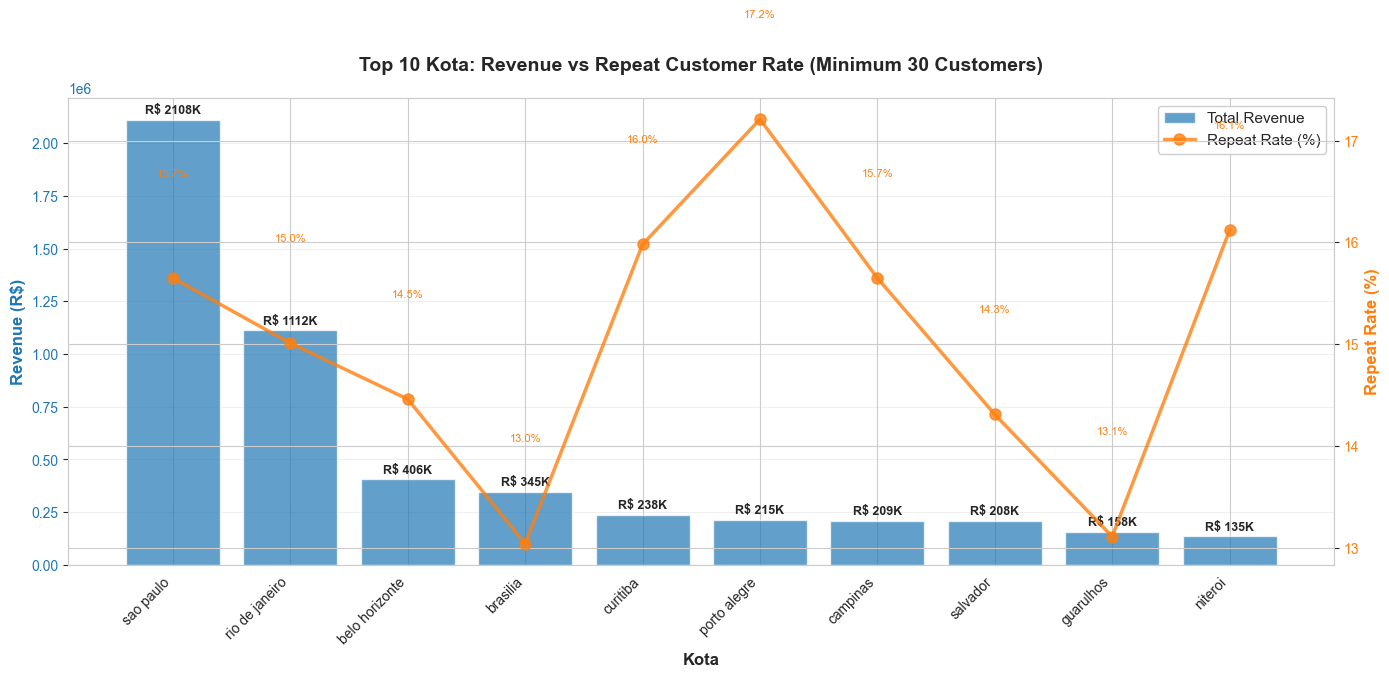


✓ Visualisasi Chart 1 Pertanyaan 2 selesai!


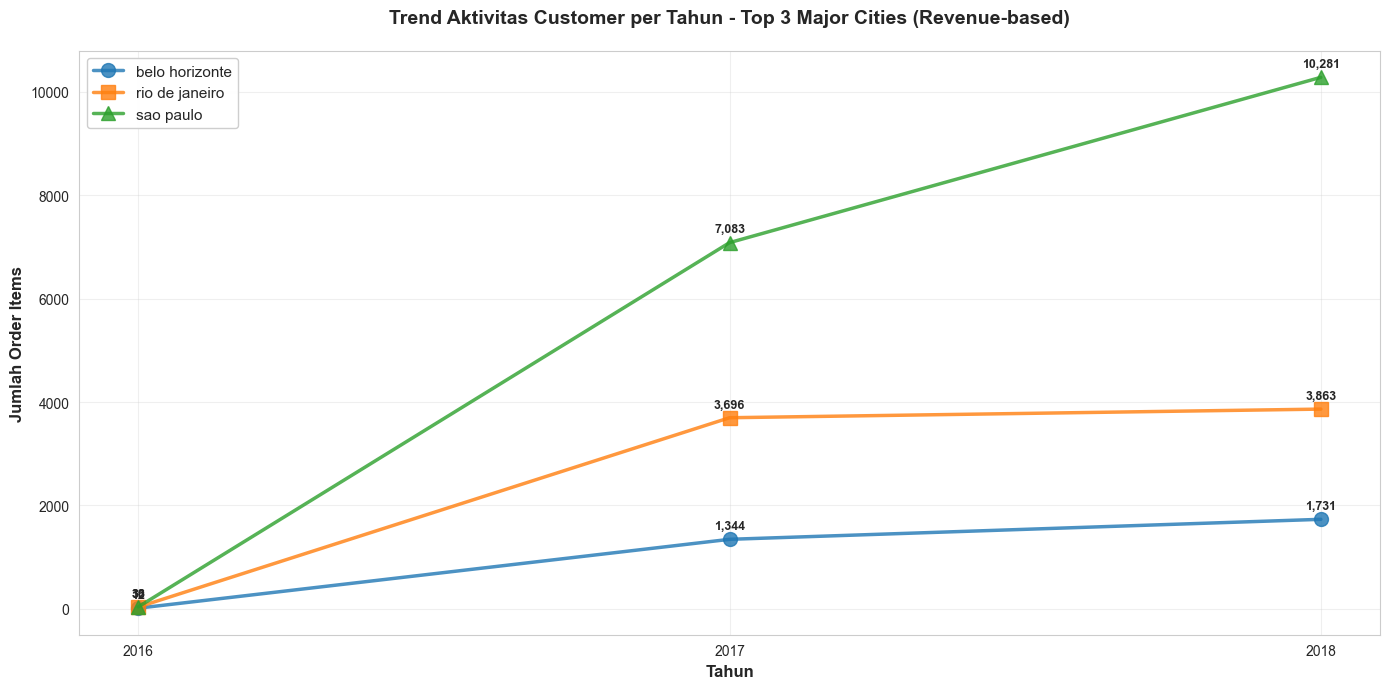

In [14]:
# ===== VISUALISASI PERTANYAAN 2 =====
print("\n" + "=" * 70)
print("VISUALIZATION: PERTANYAAN 2 - CUSTOMER LOYALTY & REVENUE PER KOTA")
print("=" * 70)

# Filter cities dengan minimum 30 unique customers untuk reliable analysis
city_stats = delivered_orders.groupby('customer_city').agg({
    'customer_id': 'nunique',
    'order_id': 'count',
    'revenue': 'sum'
}).rename(columns={'customer_id': 'unique_customers', 'order_id': 'total_orders'})

city_stats['repeat_rate'] = (
    (city_stats['total_orders'] - city_stats['unique_customers']) 
    / city_stats['unique_customers'] * 100
).round(2)

city_stats['avg_orders_per_customer'] = (
    city_stats['total_orders'] / city_stats['unique_customers']
).round(2)

# Filter for meaningful cities (minimum 30 customers)
meaningful_cities = city_stats[city_stats['unique_customers'] >= 30].sort_values('revenue', ascending=False)

# CHART 1: Bar Chart - Top 10 Cities by Revenue & Repeat Rate
fig, ax1 = plt.subplots(figsize=(14, 7))

top_10_cities = meaningful_cities.head(10)
x_pos = range(len(top_10_cities))

# Bar chart untuk revenue
bars = ax1.bar(x_pos, top_10_cities['revenue'], alpha=0.7, color='#1f77b4', label='Total Revenue')
ax1.set_xlabel('Kota', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue (R$)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(top_10_cities.index, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Add revenue value labels
for i, (idx, value) in enumerate(top_10_cities['revenue'].items()):
    ax1.text(i, value + 30000, f'R$ {value/1000:.0f}K', 
            ha='center', fontsize=9, fontweight='bold')

# Secondary axis untuk repeat rate
ax2 = ax1.twinx()
line = ax2.plot(x_pos, top_10_cities['repeat_rate'], color='#ff7f0e', marker='o', 
               linewidth=2.5, markersize=8, label='Repeat Rate (%)', alpha=0.8)
ax2.set_ylabel('Repeat Rate (%)', fontsize=12, fontweight='bold', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Add repeat rate value labels
for i, (idx, value) in enumerate(top_10_cities['repeat_rate'].items()):
    ax2.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=8, color='#ff7f0e')

ax1.set_title('Top 10 Kota: Revenue vs Repeat Customer Rate (Minimum 30 Customers)', 
             fontsize=14, fontweight='bold', pad=20)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11, framealpha=0.95)

ax1.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

print("\n✓ Visualisasi Chart 1 Pertanyaan 2 selesai!")

# CHART 2: Yearly Activity Trend - Top 3 Major Cities
# Ambil top 3 cities berdasarkan revenue
top_3_major_cities = meaningful_cities.head(3).index.tolist()

yearly_activity = delivered_orders[delivered_orders['customer_city'].isin(top_3_major_cities)].groupby(
    ['year', 'customer_city']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))

x_years = yearly_activity.index
colors_yearly = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers_yearly = ['o', 's', '^']

for i, city in enumerate(yearly_activity.columns):
    ax.plot(x_years, yearly_activity[city], 
           marker=markers_yearly[i], linewidth=2.5, markersize=10,
           label=city, color=colors_yearly[i], alpha=0.8)
    
    # Add value labels
    for year, value in zip(x_years, yearly_activity[city]):
        ax.text(year, value + 200, f'{int(value):,}', 
               ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Tahun', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Order Items', fontsize=12, fontweight='bold')
ax.set_title('Trend Aktivitas Customer per Tahun - Top 3 Major Cities (Revenue-based)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xticks(x_years)

plt.tight_layout()
plt.show()

**Insight:**

Pertanyaan 1 - Kategori Produk dengan Revenue Tertinggi (2018):

1. HEALTH_BEAUTY adalah kategori revenue leader dengan R$ 866,810 (10.3% market share),
   menunjukkan trend yang sangat positif dengan pertumbuhan +119% dari Januari ke Agustus

2. TOP 3 KATEGORI (health_beauty, watches_gifts, bed_bath_table) menghasilkan 26.7% dari
   total revenue, menunjukkan market concentration yang kuat pada beberapa kategori utama

3. MONTHLY TREND ANALYSIS:
   - Health_beauty: Konsisten naik setiap bulan, peak di Agustus (R$ 136K)
   - Watches_gifts: Sangat fluktuatif dengan peak di Mei (R$ 128K), turun -i Agustus (R$ 77K)
   - Bed_bath_table: Menurun gradual (-17%), terendah di Juli (R$ 68K)

4. STRATEGIC IMPLICATION:
   Prioritas: Maintain & grow health_beauty (trending up, highest revenue)
   Monitor: Watches_gifts (high volatility, need demand pattern analysis)
   Concern: Bed_bath_table (declining trend, need intervention)


Pertanyaan 2 - Kota dengan Customer Loyalty & Activity Trend:

1. SÃO PAULO adalah MARKET LEADER dengan revenue R$ 2,108K (46.8% dari top 10),
   menunjukkan pertumbuhan EXPLOSIVE dari 39 (2016) → 10,281 (2018) orders

2. REPEAT RATE KONSISTEN (13-17%) di semua top major cities, menunjukkan bahwa
   customer loyalty behavior lebih driven by product quality daripada lokasi geografis

3. YEARLY ACTIVITY PATTERNS:
   • São Paulo: Exponential growth (+26,336%), masih accelerating
   • Rio de Janeiro: Rapid growth 2016-2017, tapi plateau di 2018 (+4.5%)
   • Belo Horizonte: Steady moderate growth (+28.7% 2017-2018), momentum positif

4. HIGH-LOYALTY OPPORTUNITY:
   • Curitiba & Niteroi punya repeat rate tertinggi (16%+) meskipun revenue kecil
   • Menunjukkan strong product-market fit, potensi untuk scaling dengan acquisition

5. BUSINESS CONCERN:
   • Market concentration risk: São Paulo = 46.8% dari top 10 revenue
   • Rio de Janeiro stagnasi bisa indikasi market saturation atau competitive pressure
   • Diversification ke emerging cities krusial untuk sustainable growth

## Analisis Lanjutan (Opsional)

1. RFM ANALYSIS

Ringkasan RFM:
        Recency  Frequency  Monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    165.17
std      152.59       0.21    226.29
min        1.00       1.00      9.59
25%      114.00       1.00     63.01
50%      219.00       1.00    107.78
75%      346.00       1.00    182.51
max      714.00      15.00  13664.08

Distribusi Segmen:
Segment
Need Attention     34576
Champions          12293
Hibernating        12114
Big Spenders       11628
At Risk            11549
Loyal Customers    11198
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\2808596092.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="viridis")


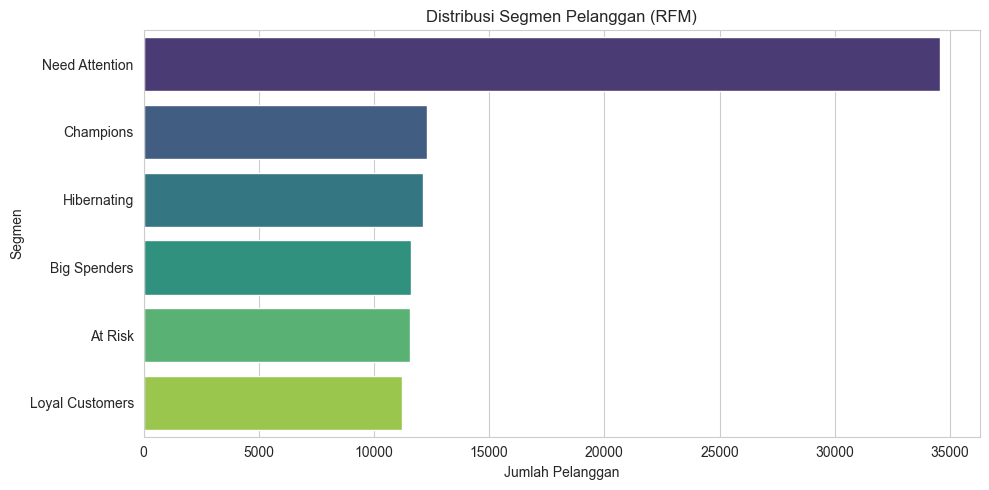

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\2808596092.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_value, x="Monetary", y="Segment", palette="magma")


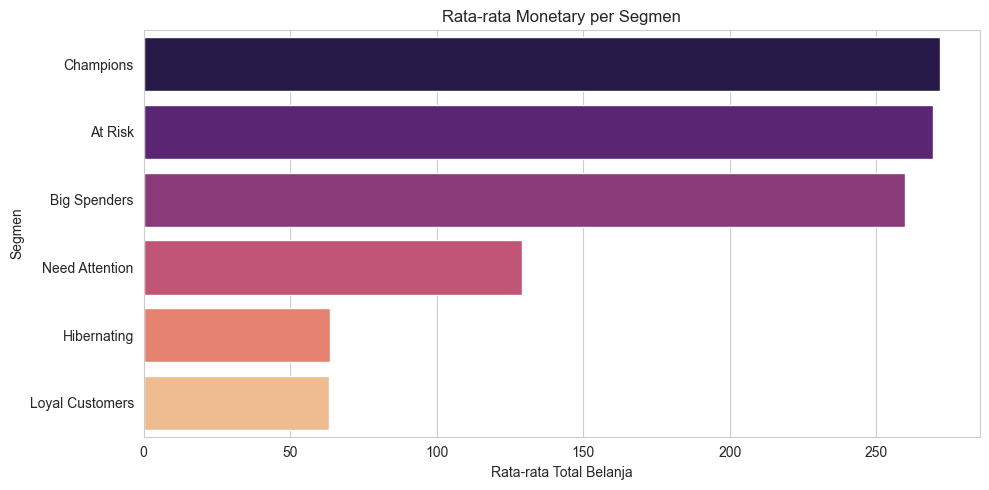

In [16]:
# =========================
# ANALISIS LANJUTAN: RFM
# =========================

# Pastikan customer_unique_id tersedia di delivered_orders
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Snapshot date untuk hitung recency
snapshot_date = delivered_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# RFM table
rfm = delivered_orders.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("revenue", "sum")
).reset_index()

# Skoring kuartil (1-4)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Segmentasi sederhana tanpa ML
conditions = [
    (rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3),
    (rfm["R_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] <= 2) & (rfm["M_Score"] <= 2)
]
choices = ["Champions", "Loyal Customers", "Big Spenders", "At Risk", "Hibernating"]
rfm["Segment"] = np.select(conditions, choices, default="Need Attention")

print("Ringkasan RFM:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

print("\nDistribusi Segmen:")
print(rfm["Segment"].value_counts())

# Visualisasi segmen
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="viridis")
plt.title("Distribusi Segmen Pelanggan (RFM)")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()

# Rata-rata Monetary per segmen
segment_value = rfm.groupby("Segment", as_index=False)["Monetary"].mean().sort_values("Monetary", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_value, x="Monetary", y="Segment", palette="magma")
plt.title("Rata-rata Monetary per Segmen")
plt.xlabel("Rata-rata Total Belanja")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()

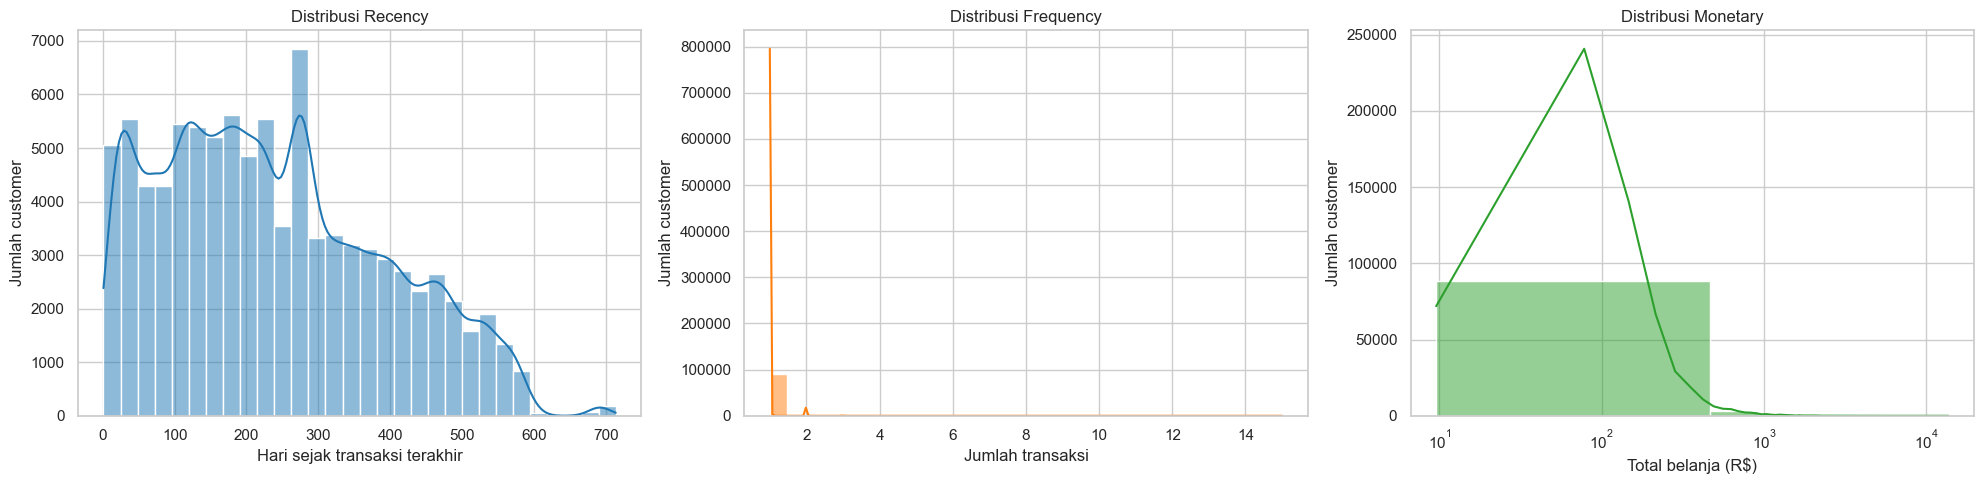

In [19]:
# =========================
# VISUALISASI SETIAP RFM
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Recency (semakin kecil semakin baik)
sns.histplot(rfm["Recency"], bins=30, kde=True, color="#1f77b4", ax=axes[0])
axes[0].set_title("Distribusi Recency")
axes[0].set_xlabel("Hari sejak transaksi terakhir")
axes[0].set_ylabel("Jumlah customer")

# 2) Frequency (jumlah transaksi)
sns.histplot(rfm["Frequency"], bins=30, kde=True, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Distribusi Frequency")
axes[1].set_xlabel("Jumlah transaksi")
axes[1].set_ylabel("Jumlah customer")

# 3) Monetary (total belanja) -> biasanya skew, pakai log scale agar terbaca
sns.histplot(rfm["Monetary"], bins=30, kde=True, color="#2ca02c", ax=axes[2])
axes[2].set_title("Distribusi Monetary")
axes[2].set_xlabel("Total belanja (R$)")
axes[2].set_ylabel("Jumlah customer")
axes[2].set_xscale("log")

plt.tight_layout()
plt.show()

**insight**
- Segmentasi RFM menunjukkan segmen Need Attention paling dominan (sekitar sepertiga total pelanggan), artinya banyak pelanggan belum cukup baru/sering/tinggi nilainya dan perlu campaign re-engagement.
- Segmen bernilai tinggi (Champions, At Risk, dan Big Spenders) memiliki rata-rata monetary tertinggi; ini menandakan kontribusi revenue terbesar datang dari kelompok pelanggan tertentu, bukan merata ke semua pelanggan.
- Rata-rata monetary segmen At Risk hampir setara dengan Champions, sehingga kelompok ini kritikal untuk diprioritaskan dalam strategi retensi (berisiko churn tapi nilainya tinggi).
- Distribusi Recency cenderung menyebar dengan konsentrasi di rentang menengah, menandakan campuran antara pelanggan aktif dan pelanggan yang mulai tidak aktif.
- Distribusi Frequency sangat right-skewed dan didominasi transaksi 1x, menunjukkan mayoritas customer masih one-time buyer; peluang terbesar ada pada peningkatan repeat purchase.
- Distribusi Monetary juga right-skewed (long tail), artinya hanya sebagian kecil pelanggan dengan belanja sangat tinggi yang mendorong nilai revenue total.
- Dari sudut clustering manual + binning, kombinasi pelanggan high spend dengan low recency perlu diperlakukan sebagai prioritas utama (retention + win-back), sedangkan pelanggan low spend dan one-time cocok untuk automasi nurture/promo dasar.

2. GEOSPATIAL ANALYSIS

In [22]:
# =========================
# GEOSPATIAL ANALYSIS
# =========================

# 1) Load geolocation data
geo_df = pd.read_csv('data/E-Commerce Public Dataset/geolocation_dataset.csv')

# 2) Siapkan data transaksi delivered + revenue per order
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'][['order_id', 'customer_id']].copy()

order_revenue = order_items_df.groupby('order_id', as_index=False).agg(
    total_revenue=('price', 'sum'),
    total_freight=('freight_value', 'sum')
)
order_revenue['gross_revenue'] = order_revenue['total_revenue'] + order_revenue['total_freight']

# 3) Gabungkan dengan customer (state, city, zip)
cust_loc = customers_df[['customer_id', 'customer_state', 'customer_city', 'customer_zip_code_prefix']].copy()

geo_sales = (
    orders_delivered
    .merge(order_revenue[['order_id', 'gross_revenue']], on='order_id', how='left')
    .merge(cust_loc, on='customer_id', how='left')
)

# 4) Ambil centroid per state dari geolocation dataset
state_centroid = geo_df.groupby('geolocation_state', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# 5) Ringkasan performa per state
state_perf = geo_sales.groupby('customer_state', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    total_customers=('customer_id', 'nunique'),
    total_revenue=('gross_revenue', 'sum')
)

state_map_df = state_perf.merge(
    state_centroid,
    left_on='customer_state',
    right_on='geolocation_state',
    how='left'
)

# =========================
# PETA 1: BUBBLE MAP PER STATE
# =========================
map_state = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='cartodbpositron')

max_rev = state_map_df['total_revenue'].max()

for _, row in state_map_df.dropna(subset=['lat', 'lng']).iterrows():
    radius = 5 + (row['total_revenue'] / max_rev) * 25
    tooltip_text = (
        f"State: {row['customer_state']}<br>"
        f"Total Revenue: R$ {row['total_revenue']:,.0f}<br>"
        f"Total Orders: {row['total_orders']:,}<br>"
        f"Total Customers: {row['total_customers']:,}"
    )

    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=radius,
        color='#1f77b4',
        fill=True,
        fill_opacity=0.65,
        tooltip=tooltip_text
    ).add_to(map_state)

map_state

In [23]:
# =========================
# PETA 2: HEATMAP BERDASARKAN ZIP CODE
# =========================

# Titik lat/lng rata-rata per zip prefix
zip_centroid = geo_df.groupby('geolocation_zip_code_prefix', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# Kinerja per zip prefix customer
zip_perf = geo_sales.groupby('customer_zip_code_prefix', as_index=False).agg(
    total_revenue=('gross_revenue', 'sum'),
    total_orders=('order_id', 'nunique')
)

zip_map_df = zip_perf.merge(
    zip_centroid,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna(subset=['lat', 'lng', 'total_revenue'])

# Data heatmap: lat, lng, weight(revenue)
heat_data = zip_map_df[['lat', 'lng', 'total_revenue']].values.tolist()

map_heat = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='cartodbpositron')

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    min_opacity=0.25,
    max_zoom=7
).add_to(map_heat)

map_heat

3. Clustering

Distribusi Manual Cluster:
manual_cluster
One-time Buyer | Low Value       72176
One-time Buyer | Mid Value       16687
One-time Buyer | High Value       1694
Occasional Buyer | Mid Value      1442
Occasional Buyer | Low Value      1193
Occasional Buyer | High Value      119
Regular Buyer | Mid Value           27
Regular Buyer | High Value          12
Power Buyer | High Value             4
Regular Buyer | Low Value            3
Power Buyer | Mid Value              1
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\3559704483.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


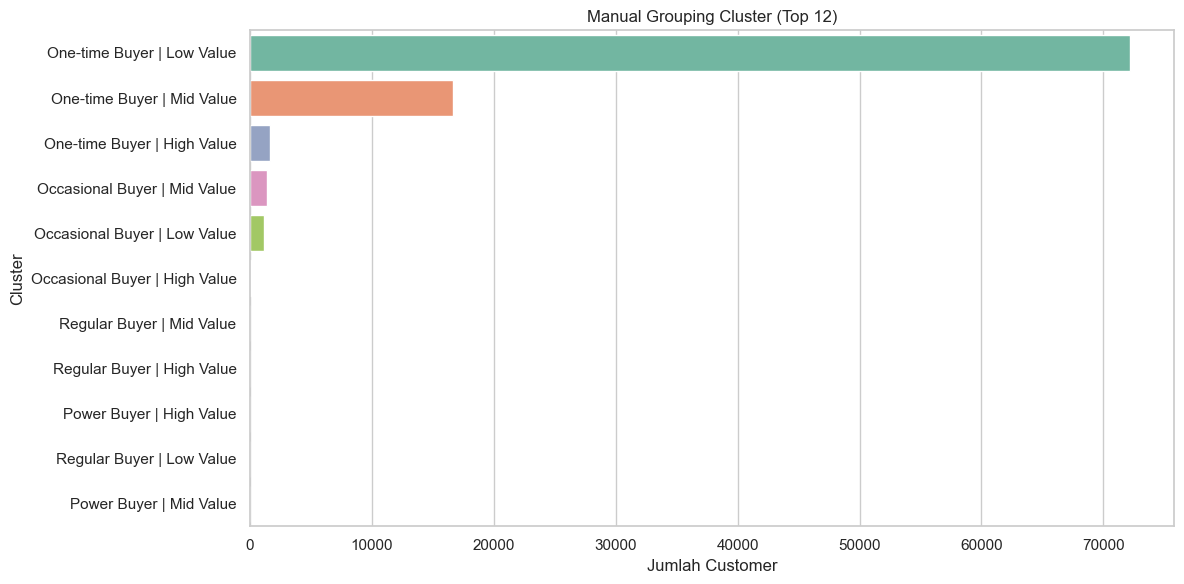


Distribusi Frequency Bin:
frequency_bin
1x      90557
2-3x     2754
4-6x       42
>6x         5
Name: count, dtype: int64

Distribusi Monetary Bin:
monetary_bin
Q1-Low        23345
Q2-MidLow     23342
Q3-MidHigh    23332
Q4-High       23339
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\3559704483.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="recency_bin", ax=axes[0], palette="Blues")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\3559704483.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="frequency_bin", ax=axes[1], palette="Oranges")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14080\3559704483.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="monetary_bin", ax=axes[2], palette="G

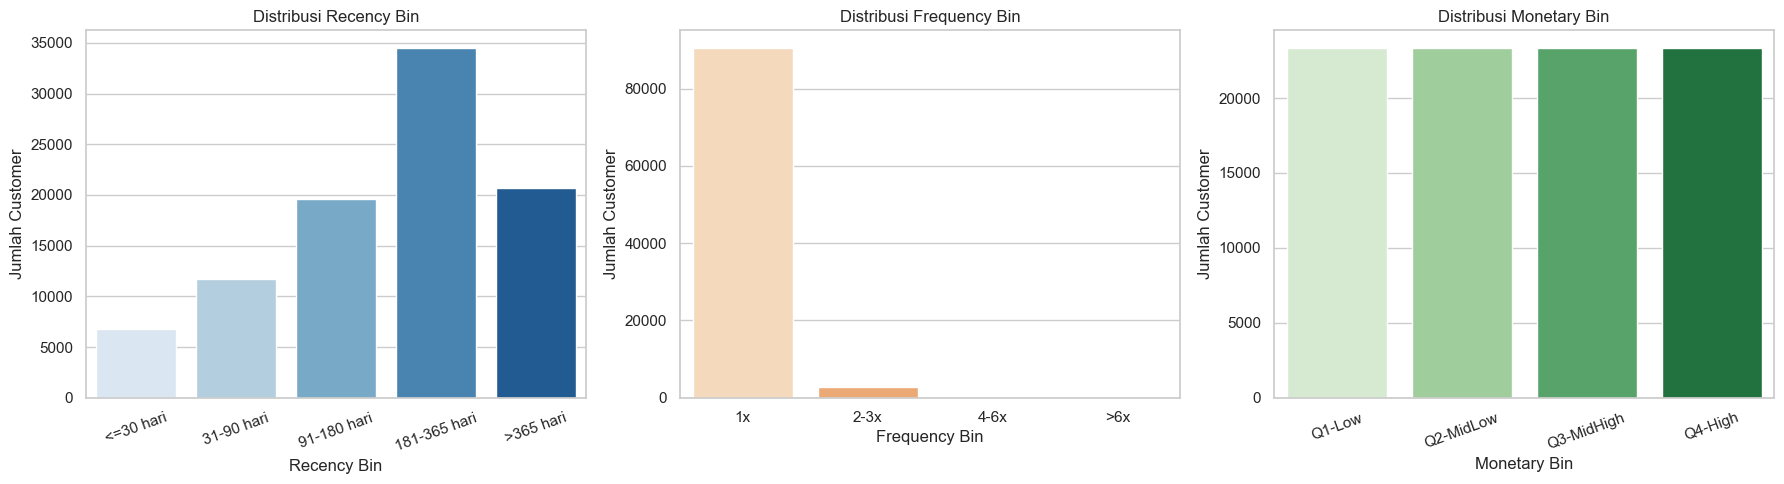


Preview hasil clustering:


,customer_unique_id,recency_days,total_orders,total_spend,manual_cluster,recency_bin,frequency_bin,monetary_bin
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,One-time Buyer | High Value,181-365 hari,1x,Q4-High
79636,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,Occasional Buyer | High Value,>365 hari,2-3x,Q4-High
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,One-time Buyer | High Value,31-90 hari,1x,Q4-High
80463,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,One-time Buyer | High Value,>365 hari,1x,Q4-High
25436,459bef486812aa25204be022145caa62,35,1,6922.21,One-time Buyer | High Value,31-90 hari,1x,Q4-High
93081,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.66,One-time Buyer | High Value,>365 hari,1x,Q4-High
23411,4007669dec559734d6f53e029e360987,279,1,6081.54,One-time Buyer | High Value,181-365 hari,1x,Q4-High
87148,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.34,One-time Buyer | High Value,>365 hari,1x,Q4-High
26640,48e1ac109decbb87765a3eade6854098,69,1,4681.78,One-time Buyer | High Value,31-90 hari,1x,Q4-High
73127,c8460e4251689ba205045f3ea17884a1,22,4,4655.88,Regular Buyer | High Value,<=30 hari,4-6x,Q4-High


In [24]:
# ==========================================
# CLUSTERING NON-ML: MANUAL GROUPING + BINNING
# ==========================================

# Pastikan customer_unique_id ada
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Snapshot date untuk recency
snapshot_date = delivered_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Ringkasan customer-level
cust_cluster = delivered_orders.groupby("customer_unique_id", as_index=False).agg(
    last_purchase=("order_purchase_timestamp", "max"),
    total_orders=("order_id", "nunique"),
    total_spend=("revenue", "sum")
)

cust_cluster["recency_days"] = (snapshot_date - cust_cluster["last_purchase"]).dt.days
cust_cluster["avg_order_value"] = cust_cluster["total_spend"] / cust_cluster["total_orders"]

# ------------------------------------------
# 1) MANUAL GROUPING (berdasarkan aturan bisnis)
# ------------------------------------------

# Group berdasarkan jumlah transaksi
conditions_freq = [
    cust_cluster["total_orders"] == 1,
    cust_cluster["total_orders"].between(2, 3),
    cust_cluster["total_orders"].between(4, 6),
    cust_cluster["total_orders"] >= 7
]
choices_freq = ["One-time Buyer", "Occasional Buyer", "Regular Buyer", "Power Buyer"]
cust_cluster["manual_freq_group"] = np.select(conditions_freq, choices_freq, default="Unclassified")

# Group berdasarkan total belanja (threshold bisnis sederhana)
conditions_spend = [
    cust_cluster["total_spend"] < 200,
    cust_cluster["total_spend"].between(200, 800, inclusive="left"),
    cust_cluster["total_spend"] >= 800
]
choices_spend = ["Low Value", "Mid Value", "High Value"]
cust_cluster["manual_spend_group"] = np.select(conditions_spend, choices_spend, default="Unclassified")

# Gabungan cluster manual
cust_cluster["manual_cluster"] = cust_cluster["manual_freq_group"] + " | " + cust_cluster["manual_spend_group"]

print("Distribusi Manual Cluster:")
print(cust_cluster["manual_cluster"].value_counts().head(15))

# Visualisasi manual grouping
plt.figure(figsize=(12, 6))
sns.countplot(
    data=cust_cluster,
    y="manual_cluster",
    order=cust_cluster["manual_cluster"].value_counts().index[:12],
    palette="Set2"
)
plt.title("Manual Grouping Cluster (Top 12)")
plt.xlabel("Jumlah Customer")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# ------------------------------------------
# 2) BINNING (interval/kategori)
# ------------------------------------------

# Binning recency (days since last purchase)
cust_cluster["recency_bin"] = pd.cut(
    cust_cluster["recency_days"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["<=30 hari", "31-90 hari", "91-180 hari", "181-365 hari", ">365 hari"]
)

# Binning frequency (jumlah order)
cust_cluster["frequency_bin"] = pd.cut(
    cust_cluster["total_orders"],
    bins=[0, 1, 3, 6, np.inf],
    labels=["1x", "2-3x", "4-6x", ">6x"]
)

# Binning monetary (berbasis kuartil agar seimbang)
cust_cluster["monetary_bin"] = pd.qcut(
    cust_cluster["total_spend"],
    q=4,
    labels=["Q1-Low", "Q2-MidLow", "Q3-MidHigh", "Q4-High"]
)

# Cluster code dari binning
cust_cluster["binning_cluster"] = (
    cust_cluster["recency_bin"].astype(str) + " | " +
    cust_cluster["frequency_bin"].astype(str) + " | " +
    cust_cluster["monetary_bin"].astype(str)
)

print("\nDistribusi Frequency Bin:")
print(cust_cluster["frequency_bin"].value_counts().sort_index())

print("\nDistribusi Monetary Bin:")
print(cust_cluster["monetary_bin"].value_counts().sort_index())

# Visualisasi binning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=cust_cluster, x="recency_bin", ax=axes[0], palette="Blues")
axes[0].set_title("Distribusi Recency Bin")
axes[0].set_xlabel("Recency Bin")
axes[0].set_ylabel("Jumlah Customer")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=cust_cluster, x="frequency_bin", ax=axes[1], palette="Oranges")
axes[1].set_title("Distribusi Frequency Bin")
axes[1].set_xlabel("Frequency Bin")
axes[1].set_ylabel("Jumlah Customer")

sns.countplot(data=cust_cluster, x="monetary_bin", ax=axes[2], palette="Greens")
axes[2].set_title("Distribusi Monetary Bin")
axes[2].set_xlabel("Monetary Bin")
axes[2].set_ylabel("Jumlah Customer")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Tabel contoh hasil clustering
cluster_preview = cust_cluster[[
    "customer_unique_id", "recency_days", "total_orders", "total_spend",
    "manual_cluster", "recency_bin", "frequency_bin", "monetary_bin"
]].sort_values(["total_spend", "total_orders"], ascending=False)

print("\nPreview hasil clustering:")
display(cluster_preview.head(20))

**insight CLustering Manual + Binning**
- Struktur pelanggan sangat didominasi pembeli sekali transaksi.
One-time Buyer totalnya 90,557 dari 93,358 pelanggan, sekitar 97.0%.
Ini konsisten dengan Frequency Bin 1x yang juga 90,557.
- Segmen terbesar adalah One-time Buyer | Low Value dengan 72,176 pelanggan, sekitar 77.3% dari total.
Artinya mayoritas pelanggan masih berkontribusi kecil dan belum repeat.
- Segmen One-time Buyer | Mid Value masih cukup besar, 16,687 pelanggan atau sekitar 17.9%. Ini adalah kandidat terbaik untuk program konversi dari first purchase ke second purchase.
- Pelanggan berulang masih sangat kecil.
2-3x hanya 2,754 pelanggan sekitar 2.95%, 4-6x hanya 42, dan lebih dari 6x hanya 5. Jadi bottleneck utama bisnis adalah retensi, bukan akuisisi awal.
- Segmen bernilai tinggi tapi loyal (Regular/Power, High Value) sangat sedikit. Ini menunjukkan customer base bernilai tinggi jangka panjang belum terbentuk kuat.
- Dari recency bin, porsi terbesar terlihat pada rentang 181-365 hari. Ini menandakan banyak pelanggan sudah lama tidak belanja dan masuk kategori win-back target.
- Monetary bin terlihat seimbang karena dibuat dengan qcut kuartil. Jadi grafik ini berguna untuk pembagian kelompok, tetapi bukan bukti distribusi alami belanja.
- Implikasi bisnis:
   - prioritas 1 adalah reactivation campaign untuk pelanggan 91-365 hari,
   - prioritas 2 adalah mendorong pembeli 1x menjadi 2x lewat voucher repeat order dan bundling,
   - prioritas 3 adalah perlakuan VIP untuk kelompok High Value agar tidak churn.

## Conclusion

- Conclution pertanyaan 1

Pada tahun 2018, kategori health_beauty menjadi kontributor revenue terbesar dan menunjukkan tren pertumbuhan paling kuat, sehingga layak menjadi fokus utama strategi pertumbuhan. Revenue juga cukup terkonsentrasi pada tiga kategori teratas (health_beauty, watches_gifts, bed_bath_table), yang berarti performa bisnis sangat dipengaruhi kategori-kategori kunci. Namun, pola antar kategori berbeda: health_beauty konsisten meningkat, watches_gifts cenderung volatil, dan bed_bath_table menurun. Karena itu, strategi yang tepat adalah mempertahankan momentum health_beauty, menstabilkan watches_gifts, dan melakukan intervensi untuk pemulihan bed_bath_table.

- Conclution pertanyaan 2

Dari sisi wilayah, São Paulo adalah pasar paling dominan dan motor utama pertumbuhan order serta revenue, tetapi dominasi ini juga menciptakan risiko konsentrasi pasar. Kota-kota besar menunjukkan repeat rate yang relatif mirip (sekitar 13–17%), sehingga loyalitas pelanggan tampak lebih dipengaruhi value produk dan pengalaman belanja dibanding lokasi semata. Sementara itu, kota seperti Curitiba dan Niteroi menunjukkan repeat rate tinggi meski skala revenue masih kecil, sehingga berpotensi menjadi area ekspansi. Secara keseluruhan, bisnis perlu menjaga kekuatan di kota utama sambil mendorong diversifikasi ke kota berkembang agar pertumbuhan lebih stabil dan berkelanjutan.

In [ ]:
# Membuat main_data.py
# Pastikan customer_unique_id ada
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Pilih kolom inti untuk dashboard
main_data = delivered_orders[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "year",
        "month",
        "customer_city",
        "customer_state",
        "product_category_name_english",
        "revenue",
        "price",
        "freight_value"
    ]
].copy()

# Rapikan missing category
main_data["product_category_name_english"] = (
    main_data["product_category_name_english"]
    .fillna("uncategorized")
)

# Simpan ke folder dashboard
os.makedirs("dashboard", exist_ok=True)
main_data.to_csv("dashboard/main_data.csv", index=False)

print("Berhasil membuat: dashboard/main_data.csv")
print("Shape:", main_data.shape)
main_data.head()